# Data Analysis and Model Evaluation for Tg Prediction

This notebook analyzes meteorological variables, evaluates their relationships, and tests different Multiple Linear Regression configurations for predicting globe temperature (Tg). Model performance is compared using standard statistical metrics.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path

# Machine learning model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Statistical analysis
import statsmodels.api as sm

# Visualization and regression analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Folders
base = Path.cwd().parent
data = base / "data"
results = base / "results"

### Read the files for 2025

In [ ]:
ds_JFM_25 = pd.read_csv(data / "JFM_2025.csv")

ds_JFM_25.tail(3)

,time,Tg,T,RH,W,SR
4817,2025-03-31 15:50:00,28.22,26.7,73,1.8,130
4818,2025-03-31 15:55:00,28.38,26.4,74,1.8,140
4819,2025-03-31 16:00:00,28.50,26.3,74,1.8,135


### Exploratory Analysis

In [13]:
# Variable Statistics


# Variables for descriptive statistics
variables_2025 = ['Tg', 'T', 'RH', 'W', 'SR']

# Generate summary statistics
summary_list_2025 = []

for var in variables_2025:
    summary_list_2025.append({
        'Variable': var,
        'Max': ds_JFM_25[var].max(),
        'Min': ds_JFM_25[var].min(),
        'Mean': ds_JFM_25[var].mean(),
        'Std': ds_JFM_25[var].std()
    })

# Convert to DataFrame
summary_table_2025 = pd.DataFrame(summary_list_2025)

# Round numerical values
summary_table_2025[['Max', 'Min', 'Mean', 'Std']] = (
    summary_table_2025[['Max', 'Min', 'Mean', 'Std']].round(2)
)

# Save
summary_table_2025.to_csv(
    results / "summary_statistics_JFM_2025.csv",
    index=False
)

# Display table
summary_table_2025

,Variable,Max,Min,Mean,Std
0,Tg,47.06,25.96,37.80,3.12
1,T,32.30,23.20,28.49,1.58
2,RH,98.00,56.00,70.82,6.41
3,W,4.90,0.00,2.44,0.64
4,SR,1042.00,46.00,681.22,208.12


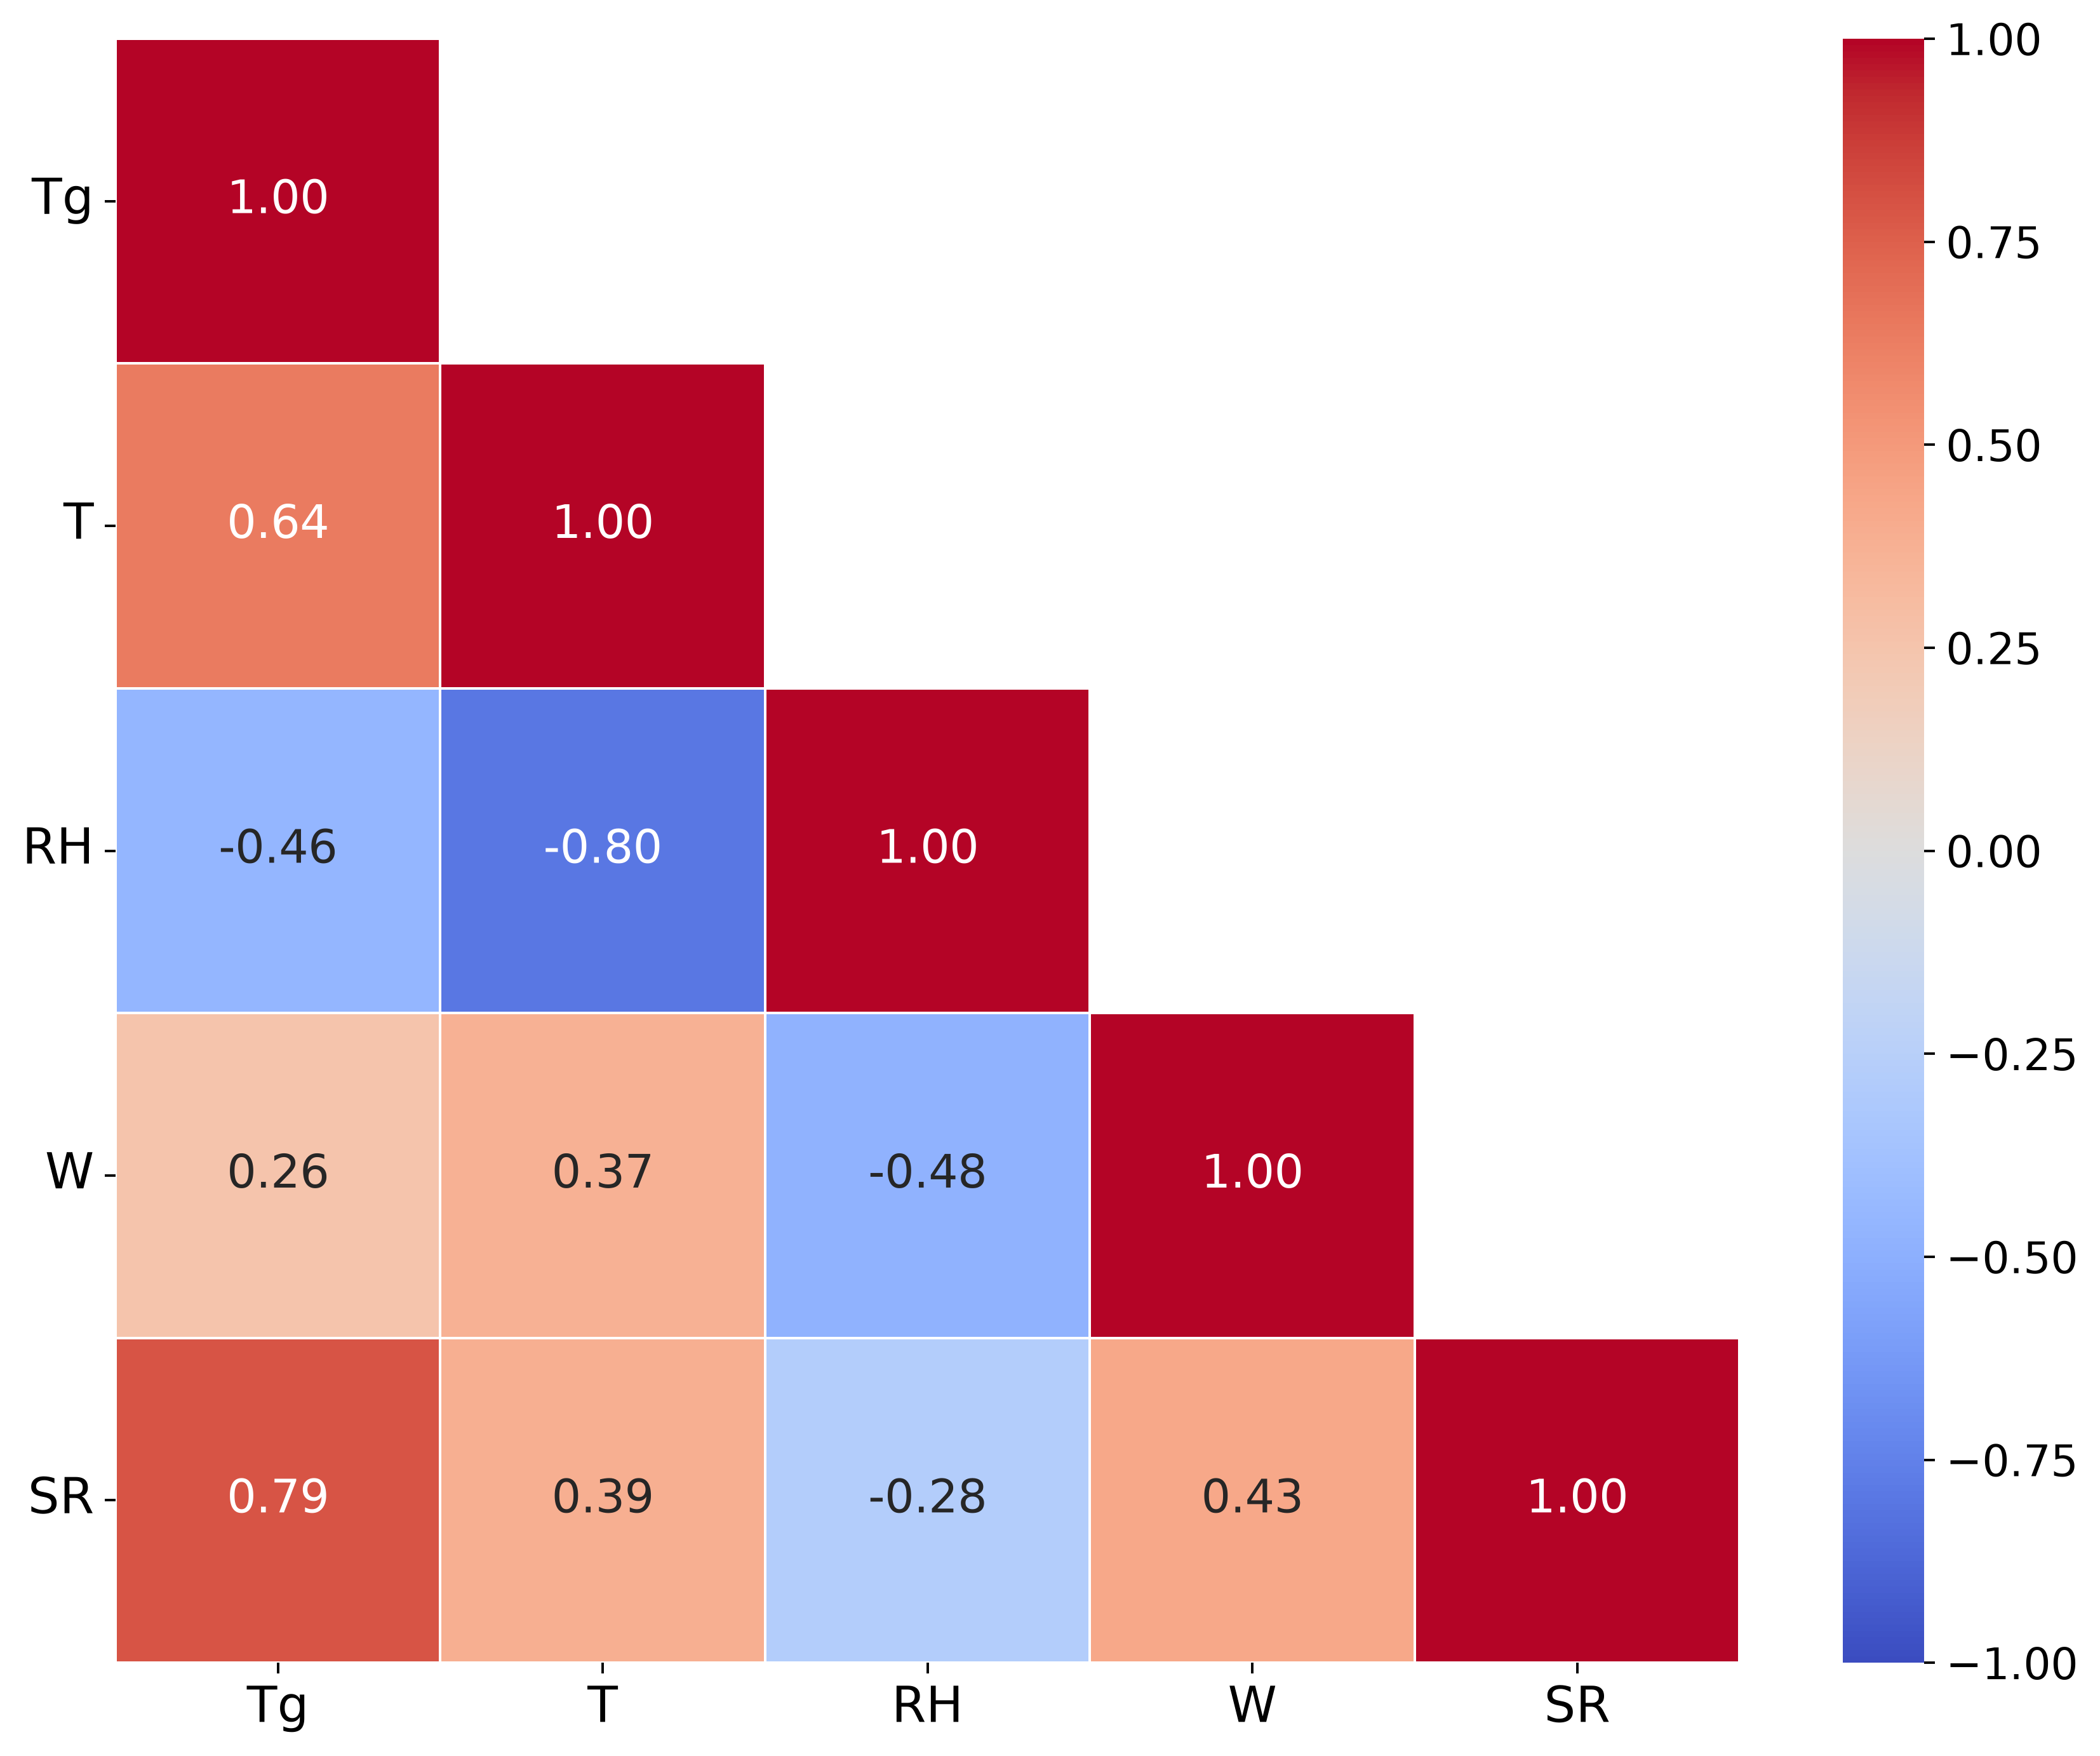

In [14]:
# Correlation


# Variables for correlation analysis
variables_corr_2025 = ['Tg', 'T', 'RH', 'W', 'SR']

# Select variables
data_corr_2025 = ds_JFM_25[variables_corr_2025]

# Correlation matrix
corr_2025 = data_corr_2025.corr()

# Mask upper triangle excluding diagonal
mask_2025 = np.triu(
    np.ones_like(corr_2025, dtype=bool),
    k=1
)

# Heatmap
plt.figure(figsize=(10, 8), dpi=350)

sns.heatmap(
    corr_2025,
    mask=mask_2025,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 15},
    vmin=-1,
    vmax=1,
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.xticks(fontsize=16, rotation=0)
plt.yticks(fontsize=16, rotation=0)

# Color bar size
cbar_2025 = plt.gcf().axes[-1]
cbar_2025.tick_params(labelsize=14)

plt.title("", fontsize=16)

plt.tight_layout()

# Save
plt.savefig(
    results / "correlation_heatmap_JFM_2025.png",
    dpi=500,
    bbox_inches="tight"
)

corr_2025.to_csv(
    results / "correlation_matrix_JFM_2025.csv"
)

plt.show()

In [16]:
# Multiple Linear Regression variable combination analysis (JFM 2025)

import itertools
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


# Predictor variables and target variable
X_vars_2025 = ["T", "RH", "W", "SR"]
y_mlr_selection_2025 = ds_JFM_25["Tg"]


results_mlr_selection_2025 = []

# Test all possible variable combinations
for k in range(1, len(X_vars_2025) + 1):

    for subset in itertools.combinations(X_vars_2025, k):

        X_mlr_selection_2025 = ds_JFM_25[list(subset)]

        # Train-test split
        X_train_sel_2025, X_test_sel_2025, y_train_sel_2025, y_test_sel_2025 = train_test_split(
            X_mlr_selection_2025,
            y_mlr_selection_2025,
            test_size=0.20,
            random_state=90
        )

        # Linear regression model
        mlr_selection_model_2025 = LinearRegression()

        mlr_selection_model_2025.fit(
            X_train_sel_2025,
            y_train_sel_2025
        )

        # Prediction
        y_pred_sel_2025 = mlr_selection_model_2025.predict(
            X_test_sel_2025
        )

        # Performance metrics
        mae_sel_2025 = mean_absolute_error(
            y_test_sel_2025,
            y_pred_sel_2025
        )

        rmse_sel_2025 = np.sqrt(
            mean_squared_error(
                y_test_sel_2025,
                y_pred_sel_2025
            )
        )

        r2_sel_2025 = r2_score(
            y_test_sel_2025,
            y_pred_sel_2025
        )

        results_mlr_selection_2025.append({
            "Variables": ", ".join(subset),
            "Num_Variables": len(subset),
            "MAE": mae_sel_2025,
            "RMSE": rmse_sel_2025,
            "R2": r2_sel_2025
        })


# Convert results to DataFrame
mlr_selection_table_2025 = pd.DataFrame(results_mlr_selection_2025)

# Sort by R² performance
mlr_selection_table_2025 = (
    mlr_selection_table_2025
    .sort_values(by="R2", ascending=False)
    .reset_index(drop=True)
)

# Round metrics
mlr_selection_table_2025[['MAE', 'RMSE', 'R2']] = (
    mlr_selection_table_2025[['MAE', 'RMSE', 'R2']].round(3)
)

mlr_selection_table_2025.to_csv(
    results / "MLR_variable_selection_JFM_2025.csv",
    index=False
)

# Display results
mlr_selection_table_2025

,Variables,Num_Variables,MAE,RMSE,R2
0,"T, RH, W, SR",4,1.126,1.430,0.793
1,"T, W, SR",3,1.128,1.434,0.791
2,"T, RH, SR",3,1.224,1.539,0.760
3,"T, SR",2,1.226,1.540,0.760
4,"RH, W, SR",3,1.248,1.558,0.754
5,"RH, SR",2,1.363,1.716,0.702
6,"W, SR",2,1.504,1.904,0.633
7,SR,1,1.518,1.925,0.624
8,"T, RH, W",3,1.795,2.407,0.413
9,"T, RH",2,1.800,2.419,0.407
